<a href="https://colab.research.google.com/github/Jbaner/OMDSModC_Capstone_Project/blob/main/OMDS_ModC_Week5_Banerjee_Jayeeta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score,recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay,confusion_matrix,classification_report,RocCurveDisplay
import matplotlib.pyplot as plt

In [2]:
datasource= "https://archive.ics.uci.edu/static/public/17/data.csv"

df_BreastCancer = pd.read_csv(datasource, sep=',', header=0) #loading breast cancer dataset
df_BreastCancer.sample(10, random_state=42) #printing random sample of 10 rows

,ID,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
204,87930,12.47,18.60,81.09,481.9,0.09965,0.10580,0.08005,0.03821,0.1925,...,24.64,96.05,677.9,0.14260,0.2378,0.2671,0.10150,0.3014,0.08750,B
70,859575,18.94,21.31,123.60,1130.0,0.09009,0.10290,0.10800,0.07951,0.1582,...,26.58,165.90,1866.0,0.11930,0.2336,0.2687,0.17890,0.2551,0.06589,M
131,8670,15.46,19.48,101.70,748.9,0.10920,0.12230,0.14660,0.08087,0.1931,...,26.00,124.90,1156.0,0.15460,0.2394,0.3791,0.15140,0.2837,0.08019,M
431,907915,12.40,17.68,81.47,467.8,0.10540,0.13160,0.07741,0.02799,0.1811,...,22.91,89.61,515.8,0.14500,0.2629,0.2403,0.07370,0.2556,0.09359,B
540,921385,11.54,14.44,74.65,402.9,0.09984,0.11200,0.06737,0.02594,0.1818,...,19.68,78.78,457.8,0.13450,0.2118,0.1797,0.06918,0.2329,0.08134,B
567,927241,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,39.42,184.60,1821.0,0.16500,0.8681,0.9387,0.26500,0.4087,0.12400,M
369,9012000,22.01,21.90,147.20,1482.0,0.10630,0.19540,0.24480,0.15010,0.1824,...,25.80,195.00,2227.0,0.12940,0.3885,0.4756,0.24320,0.2741,0.08574,M
29,853201,17.57,15.05,115.00,955.1,0.09847,0.11570,0.09875,0.07953,0.1739,...,19.52,134.90,1227.0,0.12550,0.2812,0.2489,0.14560,0.2756,0.07919,M
81,8611161,13.34,15.86,86.49,520.0,0.10780,0.15350,0.11690,0.06987,0.1942,...,23.19,96.66,614.9,0.15360,0.4791,0.4858,0.17080,0.3527,0.10160,B
477,911673,13.90,16.62,88.97,599.4,0.06828,0.05319,0.02224,0.01339,0.1813,...,21.80,101.20,718.9,0.09384,0.2006,0.1384,0.06222,0.2679,0.07698,B


In [3]:
df_BreastCancer["Diagnosis"]=df_BreastCancer["Diagnosis"].map({"M":0, "B":1})

In [4]:
#Target and Features
X= df_BreastCancer.drop(["Diagnosis","ID"], axis=1)
y= df_BreastCancer["Diagnosis"]
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42)

In [5]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled =  scaler.transform(X_test)

#Linear SVM
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train_scaled, y_train)
y_pred_linear = svm_linear.predict(X_test_scaled)

#Evaluation
linear_acc = accuracy_score(y_test, y_pred_linear)
cm1 = confusion_matrix(y_test, y_pred_linear)
cr1 = classification_report(y_test, y_pred_linear)
print("\nLinear SVM Confusion Matrix: \n", cm1)
print("\n Linear SVM Classification Report: \n\n", cr1)
print("\n-----------------------------------------------------------------")

#Poly SVM
svm_poly = SVC(kernel ='poly', degree=3, C=1.0)
svm_poly.fit(X_train_scaled, y_train)
y_pred_poly = svm_poly.predict(X_test_scaled)

#Evaluation
Poly_acc = accuracy_score(y_test, y_pred_poly)
cm2 = confusion_matrix(y_test, y_pred_poly)
cr2 = classification_report(y_test, y_pred_poly)
print("\nPoly SVM Confusion Matrix: \n", cm2)
print("\n Poly SVM Classification Report: \n\n", cr2)
print("\n-----------------------------------------------------------------")

#RBF (Gaussian) Kernel
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_rbf.fit(X_train_scaled, y_train)
y_pred_rbf = svm_rbf.predict(X_test_scaled)

#Evaluation
rbf_acc = accuracy_score(y_test, y_pred_rbf)
cm3 = confusion_matrix(y_test, y_pred_rbf)
cr3 = classification_report(y_test, y_pred_rbf)
print("\nRBF SVM Confusion Matrix: \n", cm3)
print("\n RBF SVM Classification Report: \n\n", cr3)





Linear SVM Confusion Matrix: 
 [[52  2]
 [ 2 87]]

 Linear SVM Classification Report: 

               precision    recall  f1-score   support

           0       0.96      0.96      0.96        54
           1       0.98      0.98      0.98        89

    accuracy                           0.97       143
   macro avg       0.97      0.97      0.97       143
weighted avg       0.97      0.97      0.97       143


-----------------------------------------------------------------

Poly SVM Confusion Matrix: 
 [[40 14]
 [ 0 89]]

 Poly SVM Classification Report: 

               precision    recall  f1-score   support

           0       1.00      0.74      0.85        54
           1       0.86      1.00      0.93        89

    accuracy                           0.90       143
   macro avg       0.93      0.87      0.89       143
weighted avg       0.92      0.90      0.90       143


-----------------------------------------------------------------

RBF SVM Confusion Matrix: 
 [[52  2

In [6]:
#Regularization in SVM Hyperparameter Tuning
param_grid = {'C': [0.01,0.1,1,10,100],
              'gamma': [0.001, 0.01, 0.1,1],
              'kernel': ['rbf']
              }
grid = GridSearchCV(SVC(),param_grid, cv=5, scoring = 'accuracy')
grid.fit(X_train_scaled, y_train)
print(grid.best_params_)



{'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}


In [7]:
#Regularization in SVM Hyperparameter Tuning
param_grid = {'C': [0.01,0.1,1,10,100],
              'gamma': [0.001, 0.01, 0.1,1],
              'kernel': ['poly']
              }
grid = GridSearchCV(SVC(),param_grid, cv=5, scoring = 'accuracy')
grid.fit(X_train_scaled, y_train)
print(grid.best_params_)

{'C': 1, 'gamma': 0.1, 'kernel': 'poly'}


In [8]:
#Regularization in SVM Hyperparameter Tuning
param_grid = {'C': [0.01,0.1,1,10,100],
              'gamma': [0.001, 0.01, 0.1,1],
              'kernel': ['linear']
              }
grid = GridSearchCV(SVC(),param_grid, cv=5, scoring = 'accuracy')
grid.fit(X_train_scaled, y_train)
print(grid.best_params_)

{'C': 0.1, 'gamma': 0.001, 'kernel': 'linear'}


In [9]:
#Hyperparameter Tuning for best model
param_grid = {'C': [0.01,0.1,1,10,100],
              'gamma': [0.001, 0.01, 0.1,1],
              'kernel': ['linear','poly','rbf']
              }
grid = GridSearchCV(SVC(),param_grid, cv=5, scoring = 'accuracy')
grid.fit(X_train_scaled, y_train)
print(grid.best_params_)

{'C': 0.1, 'gamma': 0.001, 'kernel': 'linear'}


In [10]:
#Generating best model using the best parameters
svm_linear = SVC(kernel='linear', C=0.1, gamma=0.001, random_state=42)
svm_linear.fit(X_train_scaled, y_train)
y_pred_linear2 = svm_linear.predict(X_test_scaled)
#Evaluation
linear_acc2 = accuracy_score(y_test, y_pred_linear2)
cm = confusion_matrix(y_test, y_pred_linear2)
cr = classification_report(y_test, y_pred_linear2)
print("\nLinear SVM Confusion Matrix: \n", cm)
print("\n Linear SVM Classification Report: \n\n", cr)



Linear SVM Confusion Matrix: 
 [[52  2]
 [ 1 88]]

 Linear SVM Classification Report: 

               precision    recall  f1-score   support

           0       0.98      0.96      0.97        54
           1       0.98      0.99      0.98        89

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



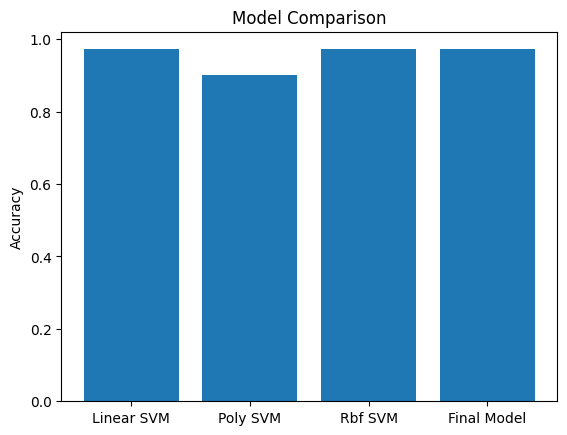

In [11]:
#Model comparison linear poly rbf and final model
plt.bar(['Linear SVM','Poly SVM','Rbf SVM','Final Model'],
        [linear_acc, Poly_acc, rbf_acc, linear_acc])
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()


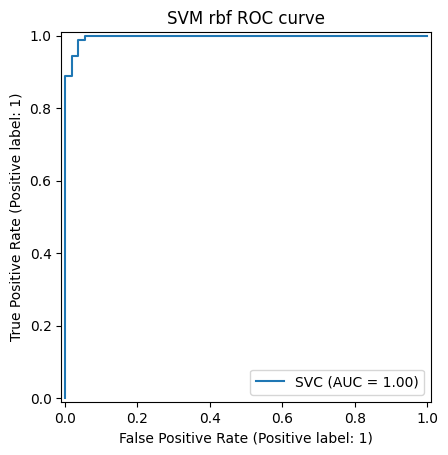

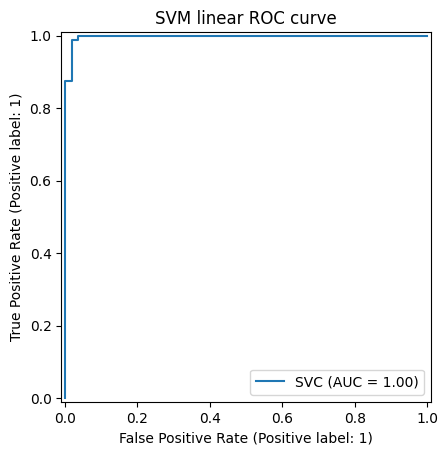

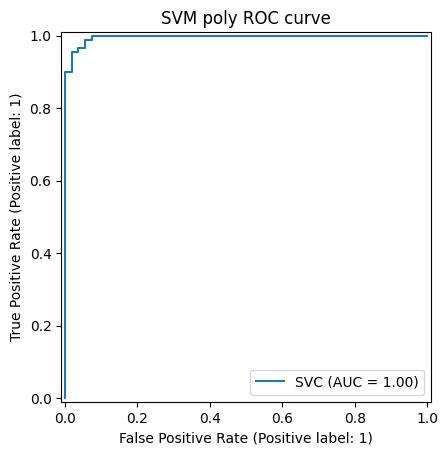

In [12]:
#Roc curve for all kernels
RocCurveDisplay.from_estimator(svm_rbf, X_test_scaled, y_test)
plt.title("SVM rbf ROC curve")
plt.show()

RocCurveDisplay.from_estimator(svm_linear, X_test_scaled, y_test)
plt.title("SVM linear ROC curve")
plt.show()

RocCurveDisplay.from_estimator(svm_poly, X_test_scaled, y_test)
plt.title("SVM poly ROC curve")
plt.show()

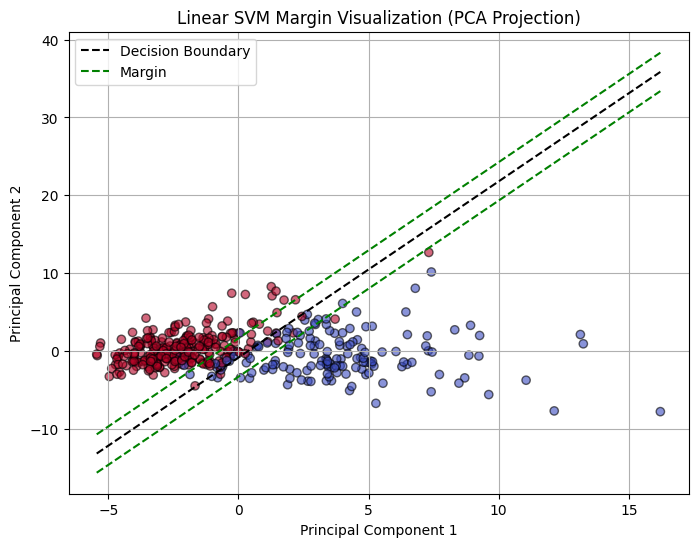

In [13]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC

#Scale and reduce dimensions using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

#Train tuned Linear SVM (from Week 5 best parameters)
svm_linear = SVC(kernel='linear', C=0.1, gamma=0.001, random_state=42)
svm_linear.fit(X_train_pca, y_train)

# Plot data points and decision boundary
plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap='coolwarm', alpha=0.6, edgecolors='k')

# Decision boundary line
w = svm_linear.coef_[0]
b = svm_linear.intercept_[0]
x_vals = np.linspace(min(X_train_pca[:,0]), max(X_train_pca[:,0]), 100)
y_vals = -(w[0]/w[1])*x_vals - b/w[1]
plt.plot(x_vals, y_vals, 'k--', label='Decision Boundary')

# Plot margins
margin = 1 / np.sqrt(np.sum(w ** 2))
y_vals_up = y_vals + np.sqrt(1 + (w[0]/w[1])**2) * margin
y_vals_down = y_vals - np.sqrt(1 + (w[0]/w[1])**2) * margin
plt.plot(x_vals, y_vals_up, 'g--', label='Margin')
plt.plot(x_vals, y_vals_down, 'g--')

# Step 5: Final formatting
plt.title("Linear SVM Margin Visualization (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
datasource= "https://archive.ics.uci.edu/static/public/383/data.csv"

df_CivicalCancer = pd.read_csv(datasource, sep=',', header=0) #loading breast cancer dataset
df_CivicalCancer.sample(10, random_state=42) #printing random sample of 10 rows

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
713,16,1.0,16.0,1.0,0.0,0.0,0.000,0.0,0.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
604,23,3.0,17.0,2.0,0.0,0.0,0.000,0.0,0.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
120,33,1.0,16.0,4.0,0.0,0.0,0.000,0.0,0.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
208,27,4.0,16.0,1.0,0.0,0.0,0.000,1.0,0.67,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
380,18,3.0,15.0,1.0,1.0,2.0,0.003,1.0,0.58,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
813,20,1.0,17.0,NaN,0.0,0.0,0.000,1.0,1.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
575,17,2.0,15.0,1.0,0.0,0.0,0.000,0.0,0.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
266,21,2.0,19.0,1.0,0.0,0.0,0.000,1.0,1.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
557,27,2.0,17.0,3.0,0.0,0.0,0.000,1.0,0.25,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
822,36,3.0,20.0,2.0,0.0,0.0,0.000,1.0,6.00,0.0,...,16.0,16.0,1,0,1,1,0,0,0,0


In [15]:
df_CivicalCancer = df_CivicalCancer.drop(columns=[
    "STDs: Time since first diagnosis",
    "STDs: Time since last diagnosis",
    "STDs:cervical condylomatosis",
    "STDs:AIDS"
])
binary_cols = ["Smokes (packs/year)", "IUD (years)", "STDs (number)", "Hormonal Contraceptives (years)"]
df_CivicalCancer[binary_cols] = df_CivicalCancer[binary_cols].fillna(0)

#df_CivicalCancer[num_cols] = df_CivicalCancer[num_cols].fillna(df_CivicalCancer[num_cols].median())
df_CivicalCancer["Number of sexual partners"] = df_CivicalCancer["Number of sexual partners"].fillna(df_CivicalCancer["Number of sexual partners"].median())
df_CivicalCancer["Num of pregnancies"] = df_CivicalCancer["Num of pregnancies"].fillna(df_CivicalCancer["Num of pregnancies"].median())
df_CivicalCancer["First sexual intercourse"] = df_CivicalCancer["First sexual intercourse"].fillna(df_CivicalCancer["First sexual intercourse"].median())
df_CivicalCancer["Smokes (packs/year)"] = df_CivicalCancer["Smokes (packs/year)"].fillna(df_CivicalCancer["Smokes (packs/year)"].median())
df_CivicalCancer["IUD (years)"] = df_CivicalCancer["IUD (years)"].fillna(df_CivicalCancer["IUD (years)"].median())
df_CivicalCancer["STDs (number)"] = df_CivicalCancer["STDs (number)"].fillna(df_CivicalCancer["STDs (number)"].median())
df_CivicalCancer["STDs: Number of diagnosis"] = df_CivicalCancer["STDs: Number of diagnosis"].fillna(df_CivicalCancer["STDs: Number of diagnosis"].median())

df_CivicalCancer["Hormonal Contraceptives (years)"] = df_CivicalCancer["Hormonal Contraceptives (years)"].fillna(df_CivicalCancer["Hormonal Contraceptives (years)"].median())
df_CivicalCancer["STDs:condylomatosis"] = df_CivicalCancer["STDs:condylomatosis"].fillna(df_CivicalCancer["STDs:condylomatosis"].median())
#df_CivicalCancer["STDs:cervical condylomatosis"] = df_CivicalCancer["STDs:cervical condylomatosis"].fillna(df_CivicalCancer["STDs:cervical condylomatosis"].median())
df_CivicalCancer["STDs:vulvo-perineal condylomatosis"] = df_CivicalCancer["STDs:vulvo-perineal condylomatosis"].fillna(df_CivicalCancer["STDs:vulvo-perineal condylomatosis"].median())
df_CivicalCancer["STDs:syphilis"] = df_CivicalCancer["STDs:syphilis"].fillna(df_CivicalCancer["STDs:syphilis"].median())
df_CivicalCancer["STDs:pelvic inflammatory disease"] = df_CivicalCancer["STDs:pelvic inflammatory disease"].fillna(df_CivicalCancer["STDs:pelvic inflammatory disease"].median())
df_CivicalCancer["STDs:genital herpes"] = df_CivicalCancer["STDs:genital herpes"].fillna(df_CivicalCancer["STDs:genital herpes"].median())
df_CivicalCancer["STDs:molluscum contagiosum"] = df_CivicalCancer["STDs:molluscum contagiosum"].fillna(df_CivicalCancer["STDs:molluscum contagiosum"].median())
#df_CivicalCancer["STDs:AIDS"] = df_CivicalCancer["STDs:AIDS"].fillna(df_CivicalCancer["STDs:AIDS"].median())
df_CivicalCancer["STDs:Hepatitis B"] = df_CivicalCancer["STDs:Hepatitis B"].fillna(df_CivicalCancer["STDs:Hepatitis B"].median())
df_CivicalCancer["STDs:HPV"] = df_CivicalCancer["STDs:HPV"].fillna(df_CivicalCancer["STDs:HPV"].median())

df_CivicalCancer["Dx:HPV"] = df_CivicalCancer["Dx:HPV"].fillna(df_CivicalCancer["Dx:HPV"].mode())
df_CivicalCancer["Dx:CIN"] = df_CivicalCancer["Dx:CIN"].fillna(df_CivicalCancer["Dx:CIN"].mode())
df_CivicalCancer["Dx:Cancer"] = df_CivicalCancer["Dx:CIN"].fillna(df_CivicalCancer["Dx:Cancer"].mode())

df_CivicalCancer_nw= df_CivicalCancer[["Age","Number of sexual partners","First sexual intercourse",
                 "Num of pregnancies","Smokes (packs/year)","Hormonal Contraceptives (years)","IUD (years)","STDs (number)","STDs: Number of diagnosis",
                                    "STDs:condylomatosis", "STDs:vulvo-perineal condylomatosis",
                                    "STDs:syphilis","STDs:pelvic inflammatory disease","STDs:genital herpes",
                                    "STDs:molluscum contagiosum","STDs:Hepatitis B","STDs:HPV", "Biopsy"]]



In [16]:
import statsmodels.api as sm
#Target and Features
X= df_CivicalCancer_nw.drop(["Biopsy"], axis=1)
y= df_CivicalCancer_nw["Biopsy"]
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42)

In [17]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled =  scaler.transform(X_test)

#Linear SVM
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train_scaled, y_train)
y_pred_linear = svm_linear.predict(X_test_scaled)

#Evaluation
linear_acc = accuracy_score(y_test, y_pred_linear)
cm1 = confusion_matrix(y_test, y_pred_linear)
cr1 = classification_report(y_test, y_pred_linear)
print("\nLinear SVM Confusion Matrix: \n", cm1)
print("\n Linear SVM Classification Report: \n\n", cr1)
print("\n-----------------------------------------------------------------")

#Poly SVM
svm_poly = SVC(kernel ='poly', degree=3, C=1.0)
svm_poly.fit(X_train_scaled, y_train)
y_pred_poly = svm_poly.predict(X_test_scaled)

#Evaluation
Poly_acc = accuracy_score(y_test, y_pred_poly)
cm2 = confusion_matrix(y_test, y_pred_poly)
cr2 = classification_report(y_test, y_pred_poly)
print("\nPoly SVM Confusion Matrix: \n", cm2)
print("\n Poly SVM Classification Report: \n\n", cr2)
print("\n-----------------------------------------------------------------")

#RBF (Gaussian) Kernel
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_rbf.fit(X_train_scaled, y_train)
y_pred_rbf = svm_rbf.predict(X_test_scaled)

#Evaluation
rbf_acc = accuracy_score(y_test, y_pred_rbf)
cm3 = confusion_matrix(y_test, y_pred_rbf)
cr3 = classification_report(y_test, y_pred_rbf)
print("\nRBF SVM Confusion Matrix: \n", cm3)
print("\n RBF SVM Classification Report: \n\n", cr3)



Linear SVM Confusion Matrix: 
 [[203   0]
 [ 12   0]]

 Linear SVM Classification Report: 

               precision    recall  f1-score   support

           0       0.94      1.00      0.97       203
           1       0.00      0.00      0.00        12

    accuracy                           0.94       215
   macro avg       0.47      0.50      0.49       215
weighted avg       0.89      0.94      0.92       215


-----------------------------------------------------------------

Poly SVM Confusion Matrix: 
 [[203   0]
 [ 12   0]]

 Poly SVM Classification Report: 

               precision    recall  f1-score   support

           0       0.94      1.00      0.97       203
           1       0.00      0.00      0.00        12

    accuracy                           0.94       215
   macro avg       0.47      0.50      0.49       215
weighted avg       0.89      0.94      0.92       215


-----------------------------------------------------------------

RBF SVM Confusion Matrix: 


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [18]:
#Regularization in SVM Hyperparameter Tuning
param_grid = {'C': [0.01,0.1,1,10,100],
              'gamma': [0.001, 0.01, 0.1,1],
              'kernel': ['rbf']
              }
grid = GridSearchCV(SVC(),param_grid, cv=5, scoring = 'accuracy')
grid.fit(X_train_scaled, y_train)
print(grid.best_params_)


{'C': 0.01, 'gamma': 0.001, 'kernel': 'rbf'}


In [19]:
#Regularization in SVM Hyperparameter Tuning
param_grid = {'C': [0.01,0.1,1,10,100],
              'gamma': [0.001, 0.01, 0.1,1],
              'kernel': ['linear']
              }
grid = GridSearchCV(SVC(),param_grid, cv=5, scoring = 'accuracy')
grid.fit(X_train_scaled, y_train)
print(grid.best_params_)

{'C': 0.01, 'gamma': 0.001, 'kernel': 'linear'}


In [20]:
#Hyperparameter Tuning for best model
param_grid = {'C': [0.01,0.1,1,10,100],
              'gamma': [0.001, 0.01, 0.1,1],
              'kernel': ['linear','poly','rbf']
              }
grid = GridSearchCV(SVC(),param_grid, cv=5, scoring = 'accuracy')
grid.fit(X_train_scaled, y_train)
print(grid.best_params_)

{'C': 0.01, 'gamma': 0.001, 'kernel': 'linear'}


In [21]:
#Generating best model using the best parameters
svm_linear = SVC(kernel='linear', C=0.1, gamma=0.001, random_state=42)
svm_linear.fit(X_train_scaled, y_train)
y_pred_linear2 = svm_linear.predict(X_test_scaled)
#Evaluation
linear_acc2 = accuracy_score(y_test, y_pred_linear2)
cm = confusion_matrix(y_test, y_pred_linear2)
cr = classification_report(y_test, y_pred_linear2)
print("\nLinear SVM Confusion Matrix: \n", cm)
print("\n Linear SVM Classification Report: \n\n", cr)


Linear SVM Confusion Matrix: 
 [[203   0]
 [ 12   0]]

 Linear SVM Classification Report: 

               precision    recall  f1-score   support

           0       0.94      1.00      0.97       203
           1       0.00      0.00      0.00        12

    accuracy                           0.94       215
   macro avg       0.47      0.50      0.49       215
weighted avg       0.89      0.94      0.92       215



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


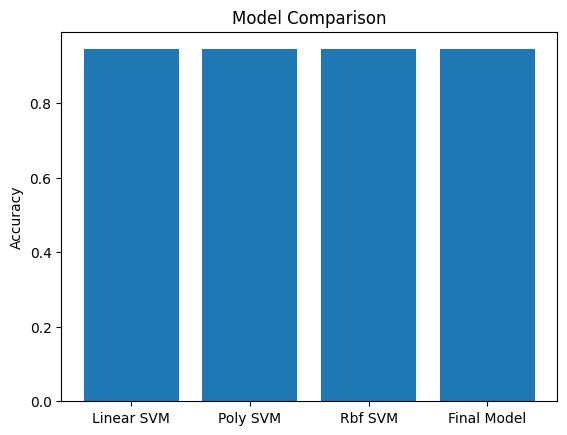

In [22]:
#Model comparison linear poly rbf and final model
plt.bar(['Linear SVM','Poly SVM','Rbf SVM','Final Model'],
        [linear_acc, Poly_acc, rbf_acc, linear_acc])
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()


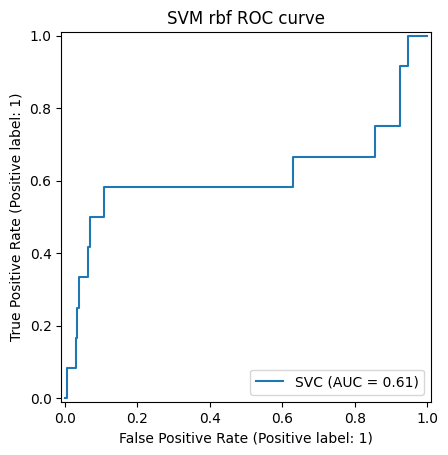

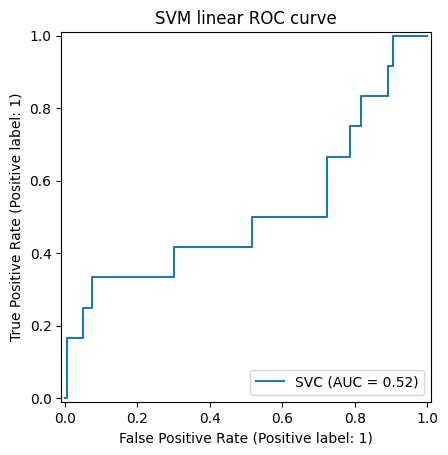

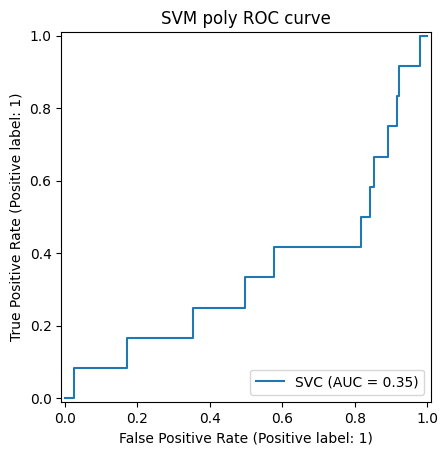

In [23]:
#Roc curve for all kernels
RocCurveDisplay.from_estimator(svm_rbf, X_test_scaled, y_test)
plt.title("SVM rbf ROC curve")
plt.show()

RocCurveDisplay.from_estimator(svm_linear, X_test_scaled, y_test)
plt.title("SVM linear ROC curve")
plt.show()

RocCurveDisplay.from_estimator(svm_poly, X_test_scaled, y_test)
plt.title("SVM poly ROC curve")
plt.show()

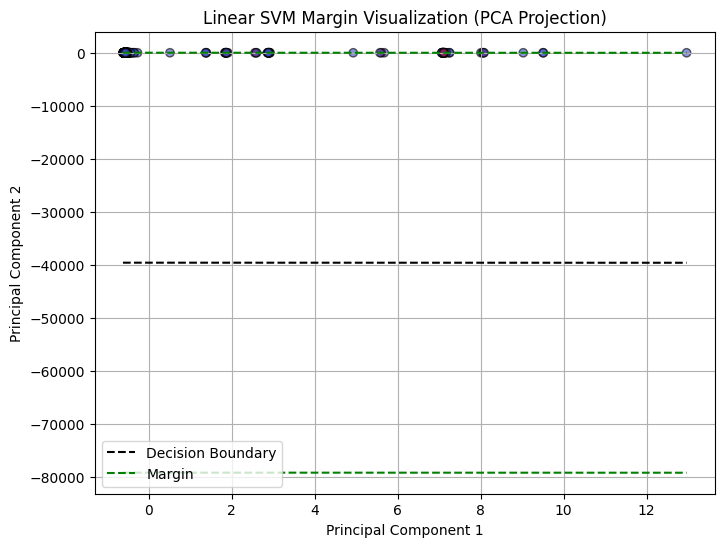

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.svm import SVC

# Step 1: Scale and reduce dimensions using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Step 2: Train tuned Linear SVM (from Week 5 best parameters)
svm_linear = SVC(kernel='linear', C=0.1, gamma=0.001, random_state=42)
svm_linear.fit(X_train_pca, y_train)

# Step 3: Plot data points and decision boundary
plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap='coolwarm', alpha=0.6, edgecolors='k')

# Decision boundary line
w = svm_linear.coef_[0]
b = svm_linear.intercept_[0]
x_vals = np.linspace(min(X_train_pca[:,0]), max(X_train_pca[:,0]), 100)
y_vals = -(w[0]/w[1])*x_vals - b/w[1]
plt.plot(x_vals, y_vals, 'k--', label='Decision Boundary')

# Step 4: Plot margins
margin = 1 / np.sqrt(np.sum(w ** 2))
y_vals_up = y_vals + np.sqrt(1 + (w[0]/w[1])**2) * margin
y_vals_down = y_vals - np.sqrt(1 + (w[0]/w[1])**2) * margin
plt.plot(x_vals, y_vals_up, 'g--', label='Margin')
plt.plot(x_vals, y_vals_down, 'g--')

# Step 5: Final formatting
plt.title("Linear SVM Margin Visualization (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()